In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv("/content/final_kaggle_cyber_dataset.csv")
df.head()

,ip_address,abuse_confidence_score,country_code,last_reported_at,country_name,continent,reported_date,reported_year,reported_month,reported_day,reported_hour,reported_weekday,label,risk_level,severity,time_zone_attack
0,213.177.179.113,100,NL,2026-04-17 18:03:45+00:00,Netherlands,Europe,2026-04-17,2026,4,17,18,Friday,Malicious,Critical,4,Evening
1,172.94.9.48,100,NL,2026-04-17 18:03:45+00:00,Netherlands,Europe,2026-04-17,2026,4,17,18,Friday,Malicious,Critical,4,Evening
2,171.25.158.73,100,SE,2026-04-17 18:03:45+00:00,Sweden,Europe,2026-04-17,2026,4,17,18,Friday,Malicious,Critical,4,Evening
3,213.209.159.235,100,DE,2026-04-17 18:03:45+00:00,Germany,Europe,2026-04-17,2026,4,17,18,Friday,Malicious,Critical,4,Evening
4,163.53.168.23,100,CN,2026-04-17 18:03:45+00:00,China,Asia,2026-04-17,2026,4,17,18,Friday,Malicious,Critical,4,Evening


In [17]:
print(df.shape)
print(df.info())
print(df.describe())

(10000, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   ip_address              10000 non-null  object
 1   abuse_confidence_score  10000 non-null  int64 
 2   country_code            10000 non-null  object
 3   last_reported_at        10000 non-null  object
 4   country_name            10000 non-null  object
 5   continent               10000 non-null  object
 6   reported_date           10000 non-null  object
 7   reported_year           10000 non-null  int64 
 8   reported_month          10000 non-null  int64 
 9   reported_day            10000 non-null  int64 
 10  reported_hour           10000 non-null  int64 
 11  reported_weekday        10000 non-null  object
 12  label                   10000 non-null  object
 13  risk_level              10000 non-null  object
 14  severity                10000 non-null  int

In [18]:
df.isnull().sum()

,0
ip_address,0
abuse_confidence_score,0
country_code,0
last_reported_at,0
country_name,0
continent,0
reported_date,0
reported_year,0
reported_month,0
reported_day,0


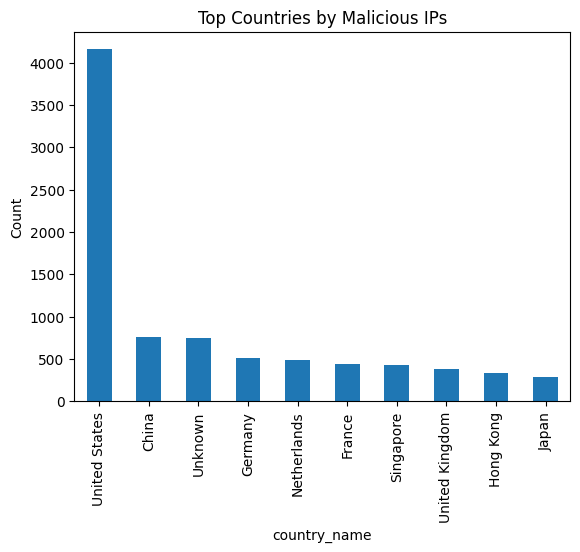

In [19]:
top_countries = df['country_name'].value_counts().head(10)

top_countries.plot(kind='bar')
plt.title("Top Countries by Malicious IPs")
plt.ylabel("Count")
plt.show()

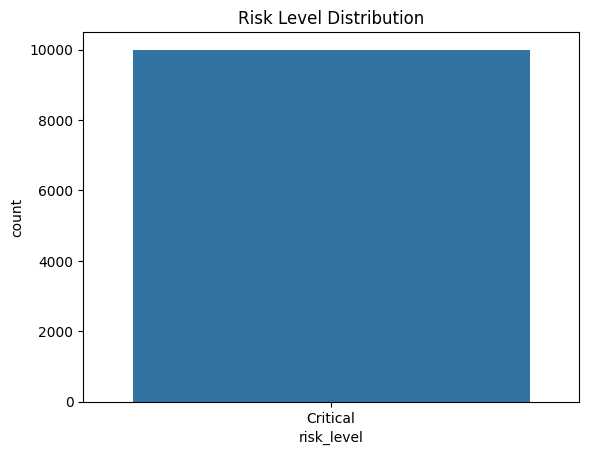

In [20]:
sns.countplot(x='risk_level', data=df)
plt.title("Risk Level Distribution")
plt.show()

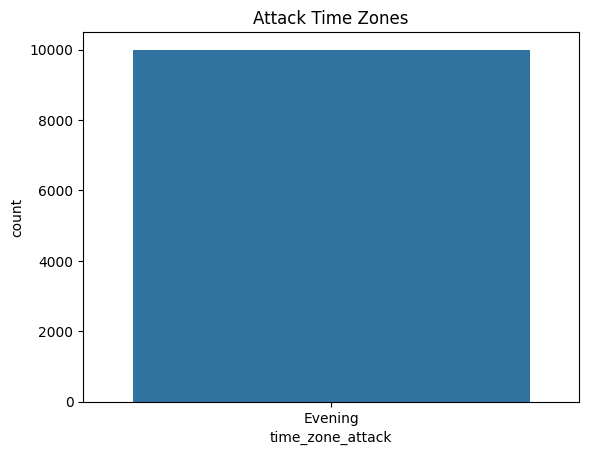

In [21]:
sns.countplot(x='time_zone_attack', data=df)
plt.title("Attack Time Zones")
plt.show()

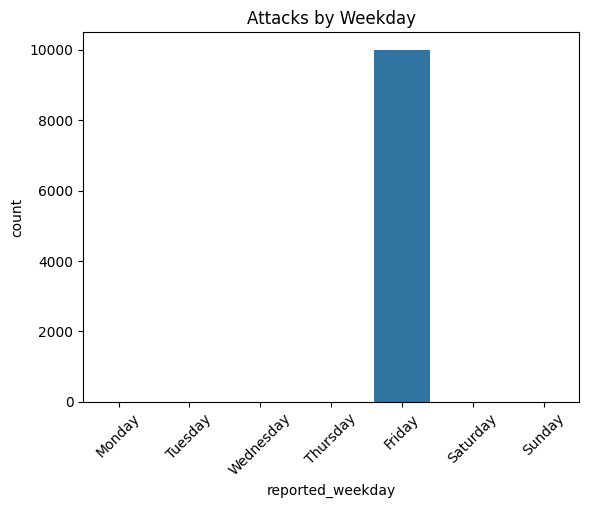

In [22]:
sns.countplot(x='reported_weekday', data=df,
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Attacks by Weekday")
plt.xticks(rotation=45)
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


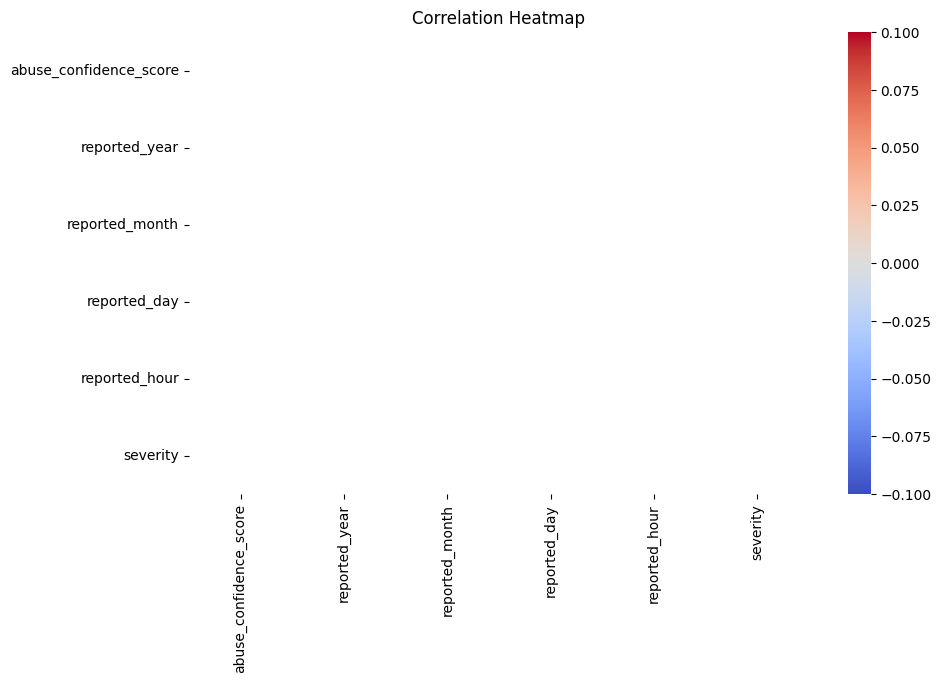

In [23]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [24]:
df['attack_intensity'] = pd.cut(df['abuse_confidence_score'],
                               bins=[0,50,80,100],
                               labels=['Low','Medium','High'])

In [25]:
df['risk_encoded'] = df['risk_level'].map({
    'Low':1, 'Medium':2, 'High':3, 'Critical':4
})